# Análise de lives de jornalismo no YouTube — notebook 1

### Grupo:
- Janderson Pereira
- Walter
- Junior Fernandes Marques `N.USP 8129363`

### Introdução

Este notebook lê o export em **Parquet** (canais brasileiros de jornalismo) e está analisando a
audiência, chat, monetização e conteúdo (transcrições). Tudo é parametrizado: troque o `video_id`,
o canal ou os parâmetros e rode de novo.


**Dependências:** `pandas`, `pyarrow`, `numpy`, `matplotlib`. O mapa (seção 11) usa `plotly`.
```
pip install pandas pyarrow numpy matplotlib plotly
```

**Arquivos usados:** `videos`, `channels`, `ccv_history`, `messages`, `author_identities`, `transcripts`.
Os operacionais (`heartbeats`, `daemon_singleton`, `ingest_log`, `schema_version`) não entram aqui.

In [1]:
# !pip install chart-studio

In [2]:
# import chart_studio
# chart_studio.tools.set_credentials_file(
#     username='SEU_USUARIO',
#     api_key='SUA_API_KEY'
# )

In [ ]:
# Bibliotecas
import os, json, re, math, html
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# >>> AJUSTE AQUI: pasta onde extrai o export <<<
DATA_DIR = "audiencia_export_2026-06-21_144011"

# Fuso de Brasília (para análises por hora/dia)
try:
    from zoneinfo import ZoneInfo
    TZ = ZoneInfo("America/Sao_Paulo")
except Exception:
    TZ = None

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "font.size": 11,
})
BLUE, AMBER, GRAY = "#2f6fb3", "#d28a18", "#8a8a8a"

def path(name): return os.path.join(DATA_DIR, name + ".parquet")

def load(name, **kw):
    "Lê um parquet do export como DataFrame."
    return pd.read_parquet(path(name), **kw)

def to_dt(series_epoch_s):
    "int64 epoch (segundos) -> datetime no fuso de Brasília."
    s = pd.to_datetime(series_epoch_s, unit="s", utc=True)
    return s.dt.tz_convert(TZ) if TZ else s

print("DATA_DIR =", os.path.abspath(DATA_DIR))
print("arquivos:", [f for f in os.listdir(DATA_DIR) if f.endswith('.parquet')])

DATA_DIR = /home/junior_marqx27/Documents/infoVis/Trabalho/audiencia_export_2026-06-21_144011
arquivos: ['transcripts.parquet', 'ccv_history.parquet', 'author_identities.parquet', 'videos.parquet', 'heartbeats.parquet', 'ingest_log.parquet', 'schema_version.parquet', 'channels.parquet', 'messages.parquet', 'daemon_singleton.parquet']


## 1. Carregando os dados

In [ ]:
channels = load("channels")
videos   = load("videos")
ccv      = load("ccv_history")

messages = load("messages", columns=[
    "video_id","author_channel_hash","video_offset_ms",
    "message_type","super_chat_amount","is_member","is_moderator"])

name_map = dict(zip(channels["handle"], channels["name"]))   
vid2ch   = dict(zip(videos["video_id"], videos["channel_handle"]))

def ch_name(h): return name_map.get(h, h)

print(f"channels : {len(channels):>9,}")
print(f"videos   : {len(videos):>9,}")
print(f"ccv      : {len(ccv):>9,}")
print(f"messages : {len(messages):>9,}")

channels :        12
videos   :     2,797
ccv      :   121,280
messages : 2,332,002


## 2. Visão geral e cobertura

In [5]:
# Período coberto
st = videos.loc[videos["actual_start"] > 0, "actual_start"]
print("Período das lives:", to_dt(pd.Series([st.min()])).iloc[0].date(),
      "->", to_dt(pd.Series([st.max()])).iloc[0].date())
print("\nCategorias (live_type):")
print(videos["live_type"].value_counts().head(6).to_string())

# Quais vídeos têm cada fonte de dado
ids_all = set(videos["video_id"])
ids_ccv = set(ccv["video_id"])
ids_msg = set(messages["video_id"])
ids_trs = set(load("transcripts", columns=["video_id"])["video_id"])
n = len(ids_all)
print(f"\nCobertura de {n} vídeos:")
print(f"  CCV (audiência) : {len(ids_ccv & ids_all):>5} ({100*len(ids_ccv&ids_all)/n:.0f}%)")
print(f"  Chat            : {len(ids_msg & ids_all):>5} ({100*len(ids_msg&ids_all)/n:.0f}%)")
print(f"  Transcrição     : {len(ids_trs & ids_all):>5} ({100*len(ids_trs&ids_all)/n:.0f}%)")
print(f"  Os três juntos  : {len(ids_ccv & ids_msg & ids_trs & ids_all):>5}")

Período das lives: 2026-04-28 -> 2026-06-21

Categorias (live_type):
live_type
News & Politics    2596
Sports              190
People & Blogs        6
Entertainment         3
Howto & Style         1

Cobertura de 2797 vídeos:
  CCV (audiência) :  1955 (70%)
  Chat            :  2308 (83%)
  Transcrição     :  2345 (84%)
  Os três juntos  :  1615


## 3. Resumo por canal

In [6]:
msgs_por_video = messages.groupby("video_id").size().rename("msgs")
vv = videos.merge(msgs_por_video, left_on="video_id", right_index=True, how="left")
vv["msgs"] = vv["msgs"].fillna(0)

resumo = (vv.groupby("channel_handle")
            .agg(lives=("video_id","count"),
                 views_totais=("view_count","sum"),
                 pico_medio=("concurrent_view_count","mean"),
                 dur_mediana_min=("duration_seconds","median"),
                 msgs=("msgs","sum"))
            .reset_index())
resumo["msgs_por_1k_views"] = (resumo["msgs"]/resumo["views_totais"]*1000).round(1)
resumo["pico_medio"] = resumo["pico_medio"].round()
resumo["dur_mediana_min"] = (resumo["dur_mediana_min"]/60).round(1)
resumo["canal"] = resumo["channel_handle"].map(name_map)
resumo = resumo.sort_values("views_totais", ascending=False)
resumo[["canal","lives","views_totais","pico_medio","dur_mediana_min","msgs_por_1k_views"]]

,canal,lives,views_totais,pico_medio,dur_mediana_min,msgs_por_1k_views
4,Revista Oeste,217,9022796.0,4296.0,127.2,31.4
0,CNN Brasil,419,5966626.0,5477.0,108.5,136.5
10,Jovem Pan News,400,4670065.0,3385.0,124.0,64.8
11,UOL,188,2431231.0,1577.0,72.5,115.0
6,Band Jornalismo,175,2254526.0,2469.0,64.2,41.6
5,SBT News,330,2046084.0,1404.0,153.0,26.3
9,ICL Notícias,89,2044558.0,1190.0,185.2,39.1
7,TV 247,391,1562424.0,557.0,63.8,114.8
8,Gazeta do Povo,123,1459195.0,867.0,180.8,33.8
2,Metrópoles TV,216,1145362.0,892.0,88.5,135.4


## 4. Curva de audiência de uma live (espectadores + chat)

`audience_curve(video_id)` cruza `ccv_history` (espectadores simultâneos) com `messages`
(velocidade do chat, via `video_offset_ms`). Troque o `video_id` para analisar qualquer live.

Live de exemplo: CsTuz3TVb4Q — CNN Brasil


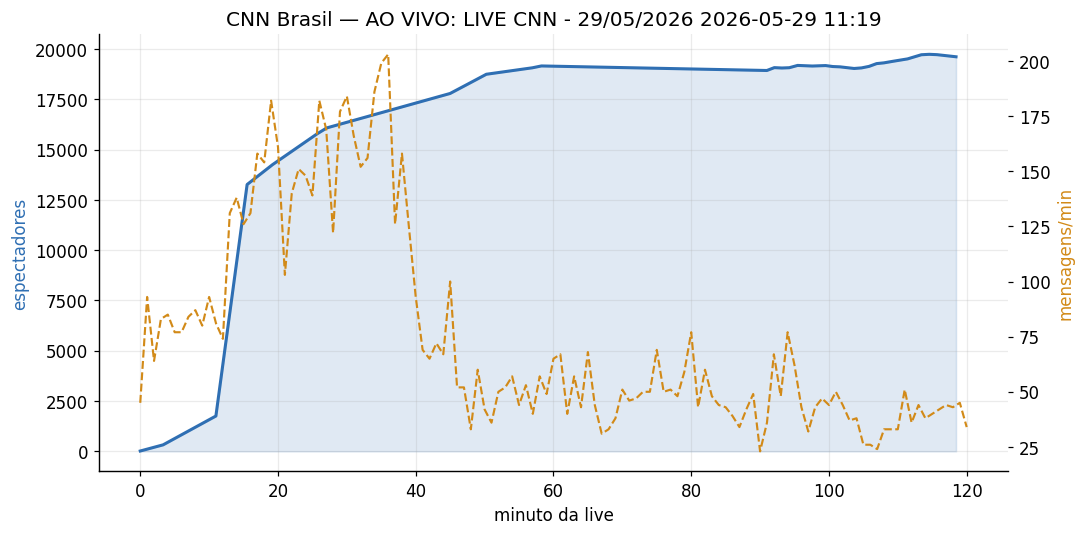

In [ ]:
def audience_curve(video_id, ax=None):
    s = ccv[ccv.video_id == video_id].sort_values("fetched_at")
    if s.empty:
        print("Sem histórico de CCV para", video_id); return
    t0 = s["fetched_at"].min()
    mins = (s["fetched_at"] - t0) / 60.0

    m = messages[messages.video_id == video_id]
    off = (m["video_offset_ms"] / 60000.0)
    off = off[(off >= 0) & (off <= mins.max() + 2)]
    vel = off.round().astype(int).value_counts().sort_index()

    if ax is None: _, ax = plt.subplots()
    ax.fill_between(mins, s["concurrent_view_count"], color=BLUE, alpha=.15)
    ax.plot(mins, s["concurrent_view_count"], color=BLUE, lw=2, label="Espectadores simultâneos")
    ax.set_xlabel("minuto da live"); ax.set_ylabel("espectadores", color=BLUE)
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(vel.index, vel.values, color=AMBER, lw=1.4, ls="--", label="Mensagens/min")
    ax2.set_ylabel("mensagens/min", color=AMBER)

    row = videos[videos.video_id == video_id]
    titulo = row["title"].iloc[0] if not row.empty else video_id
    ch = ch_name(row["channel_handle"].iloc[0]) if not row.empty else ""
    ax.set_title(f"{ch} — {str(titulo)[:60]}")
    return ax

# Live de exemplo: bem coberta (transcrição + audiência detalhada), com pico alto
_cc = ccv.groupby("video_id").size()
_cand = videos[videos["video_id"].isin(_cc[_cc >= 20].index)]
try:
    _cand = _cand[_cand["video_id"].isin(ids_trs)]   
except NameError:
    pass
exemplo = _cand.sort_values("concurrent_view_count", ascending=False)["video_id"].iloc[0]
print("Live de exemplo:", exemplo, "—", ch_name(vid2ch.get(exemplo)))
audience_curve(exemplo); plt.tight_layout(); plt.show()

# Aqui Usei a CNN, mas pode ser outra ou criar algo interativo

## 5. Audiência × intensidade de engajamento por canal

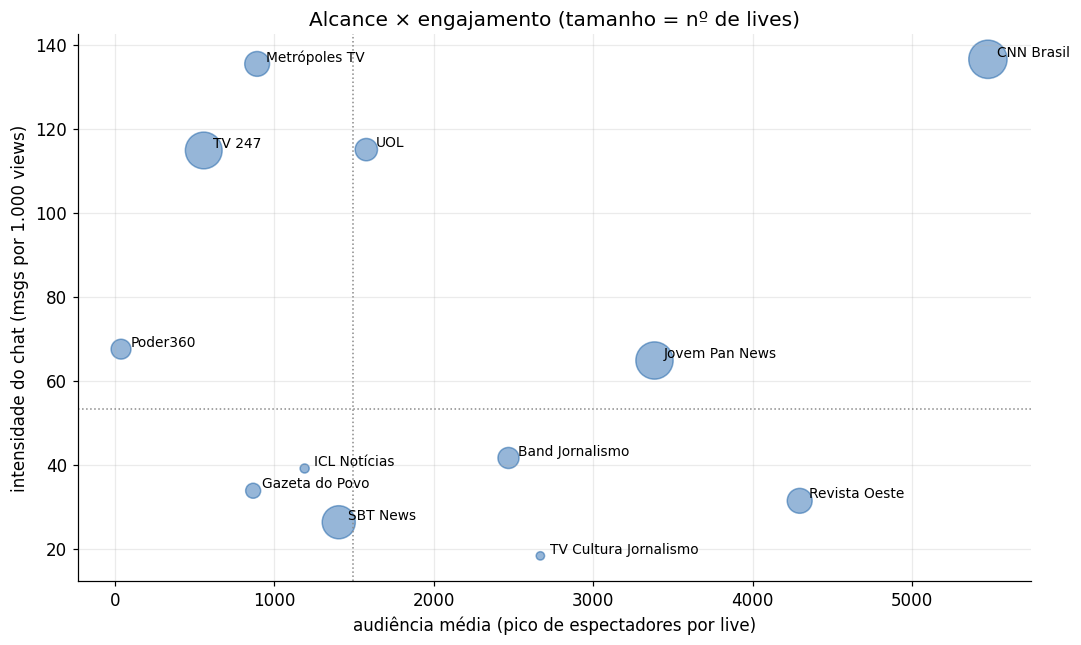

In [8]:
fig, ax = plt.subplots(figsize=(10,6))
sub = resumo.dropna(subset=["pico_medio"])
sizes = 30 + (sub["lives"] - sub["lives"].min())/(sub["lives"].max()-sub["lives"].min())*600
ax.scatter(sub["pico_medio"], sub["msgs_por_1k_views"], s=sizes, alpha=.5,
           color=BLUE, edgecolor="#185FA5")
ax.axvline(sub["pico_medio"].median(), color=GRAY, ls=":", lw=1)
ax.axhline(sub["msgs_por_1k_views"].median(), color=GRAY, ls=":", lw=1)
for _, r in sub.iterrows():
    ax.annotate(r["canal"], (r["pico_medio"], r["msgs_por_1k_views"]),
                xytext=(6,2), textcoords="offset points", fontsize=9)
ax.set_xlabel("audiência média (pico de espectadores por live)")
ax.set_ylabel("intensidade do chat (msgs por 1.000 views)")
ax.set_title("Alcance × engajamento (tamanho = nº de lives)")
plt.tight_layout(); plt.show()

## 6. Melhor horário para ir ao ar (dia × hora)

Mapa de calor da audiência por dia da semana e hora (Brasília). Usei o `agg="median"` para um
retrato mais robusto (a média é puxada por lives gigantes) e `min_n` para exigir um mínimo
de lives por célula. Discutivel esse ponto se é a melhor opção.

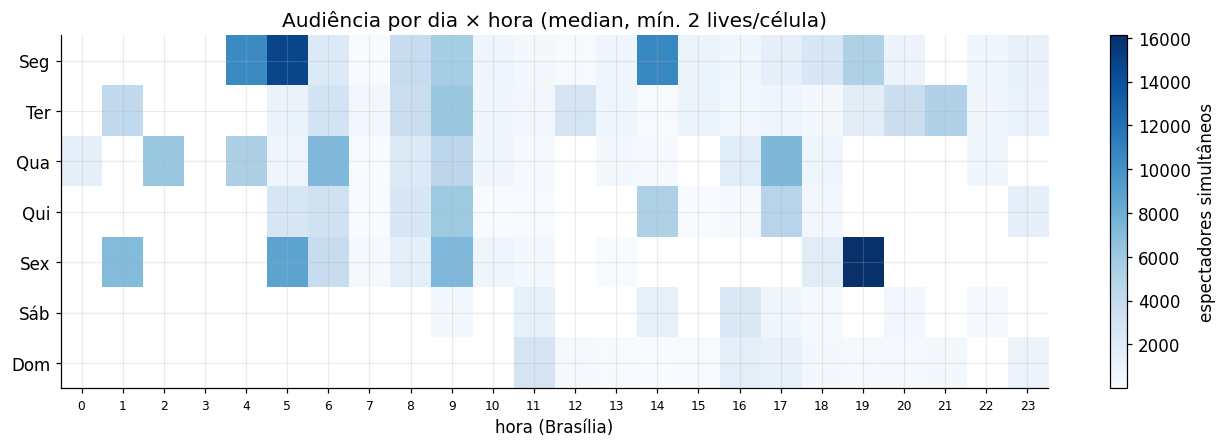

In [9]:
def heatmap_horario(agg="median", min_n=2):
    v = videos[(videos.live_status == "was_live") & (videos.actual_start > 0)].dropna(
        subset=["concurrent_view_count"]).copy()
    d = to_dt(v["actual_start"])
    v["dow"] = d.dt.dayofweek; v["hour"] = d.dt.hour
    val = v.pivot_table(index="dow", columns="hour", values="concurrent_view_count", aggfunc=agg)
    cnt = v.pivot_table(index="dow", columns="hour", values="concurrent_view_count", aggfunc="count")
    val = val.where(cnt >= min_n)
    val = val.reindex(index=range(7), columns=range(24))

    fig, ax = plt.subplots(figsize=(12,4.2))
    im = ax.imshow(val.values, aspect="auto", cmap="Blues")
    ax.set_xticks(range(24)); ax.set_xticklabels(range(24), fontsize=8)
    ax.set_yticks(range(7)); ax.set_yticklabels(["Seg","Ter","Qua","Qui","Sex","Sáb","Dom"])
    ax.set_xlabel("hora (Brasília)")
    ax.set_title(f"Audiência por dia × hora ({agg}, mín. {min_n} lives/célula)")
    fig.colorbar(im, ax=ax, label="espectadores simultâneos")
    plt.tight_layout(); plt.show()

heatmap_horario(agg="median", min_n=2)

## 7. Super chats — receita estimada por canal

Receita total em R$: 17,381.85  |  super chats em R$: 2,603


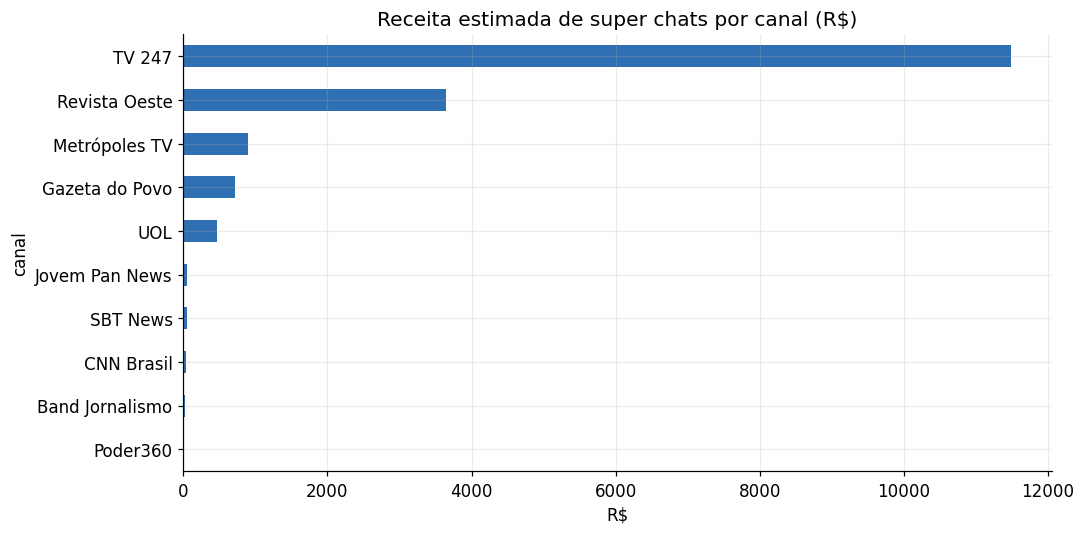

,receita,qtd
canal,,
TV 247,11479.82,2039
Revista Oeste,3646.67,282
Metrópoles TV,898.06,113
Gazeta do Povo,718.61,59
UOL,461.30,74
Jovem Pan News,58.00,10
SBT News,48.39,7
CNN Brasil,42.00,15
Band Jornalismo,27.00,3


In [10]:
def parse_brl(x):
    "Converte 'R$5.00' -> 5.0. Ignora outras moedas (retorna NaN)."
    if not isinstance(x, str): return np.nan
    x = x.replace("\xa0", " ").strip()
    if not x.startswith("R$"): return np.nan
    try: return float(re.sub(r"[^0-9.]", "", x.replace(",", "")))
    except ValueError: return np.nan

sc = messages[messages["super_chat_amount"].notna() & (messages["super_chat_amount"] != "")].copy()
sc["brl"] = sc["super_chat_amount"].map(parse_brl)
sc["canal"] = sc["video_id"].map(vid2ch).map(name_map)
rev = (sc.dropna(subset=["brl"]).groupby("canal")["brl"]
         .agg(receita="sum", qtd="count").sort_values("receita", ascending=False))
print(f"Receita total em R$: {sc['brl'].sum():,.2f}  |  super chats em R$: {sc['brl'].notna().sum():,}")

ax = rev["receita"].head(10)[::-1].plot.barh(color=BLUE)
ax.set_xlabel("R$"); ax.set_title("Receita estimada de super chats por canal (R$)")
plt.tight_layout(); plt.show()
rev

## 8. Espectadores: únicos e recorrentes (lealdade)

Usa o hash do autor das mensagens para estimar quantos comentaristas únicos cada canal tem e
qual a fração que aparece em **mais de uma live** (proxy de público fiel).

In [11]:
au = messages[["video_id","author_channel_hash"]].dropna()
au["canal"] = au["video_id"].map(vid2ch).map(name_map)
au = au.drop_duplicates(["canal","author_channel_hash","video_id"])

unicos = au.groupby("canal")["author_channel_hash"].nunique().rename("autores_unicos")
lives_por_autor = au.groupby(["canal","author_channel_hash"]).size()
recorrentes = (lives_por_autor > 1).groupby("canal").mean().rename("frac_recorrente")

lealdade = pd.concat([unicos, (recorrentes*100).round(1)], axis=1).sort_values("autores_unicos", ascending=False)
lealdade.columns = ["autores_únicos", "% recorrentes (>1 live)"]
lealdade

,autores_únicos,% recorrentes (>1 live)
canal,,
Revista Oeste,33263,40.2
UOL,18259,28.7
Jovem Pan News,18012,28.0
CNN Brasil,16922,35.9
Metrópoles TV,15895,26.3
ICL Notícias,12107,39.4
TV 247,11703,43.4
Gazeta do Povo,7527,25.5
Band Jornalismo,5820,18.0


## 9. Assunto característico por canal (transcrições)

Lê as transcrições em streaming, conta os termos de conteúdo e mostra, por
canal, as palavras que ele usa **mais que a média dos outros** (over-index). É isso que diferencia
os canais — já que todos falam de Lula/Bolsonaro/governo. No momento não vejo necessidade de aumentar esse corpus.

In [12]:
STOP = set('''a o e que de do da em um uma os as dos das no na nos nas ao à aos às por para com se sua seu suas
seus eu você ele ela nós eles elas me te lhe nos vos lhes meu minha isso isto aquilo este esta esse essa aquele
aquela não sim mais menos muito pouco já ainda também só apenas então porque pois como quando onde quem qual quais
ser estar ter haver ir vir ver dar fazer poder dizer falar saber querer dever ficar passar quero queria é são foi
era estão está sendo tem têm tinha houve vai vão vamos vou seria seriam pode podem podia aqui ali lá cá agora hoje
ontem amanhã sempre nunca tudo nada algo alguém ninguém cada todo toda todos todas bem bom boa né tá pra pro pros
pras cê tô vamo olha assim coisa coisas gente vez vezes dia dias ano anos mas ou nem porém contudo entretanto sobre
entre até desde após antes depois durante contra sob num numa isso aqui aí oh ah eh uhm hum tipo cara meio super
bastante realmente verdade certo nesse neste dessa música aplausos risos inaudível aplauso vinheta the to of and in
is are this that you we for with people be on it as quer dizer ó deu fica fazendo falando dizendo dando indo vindo
vendo fala falar falou disse dito acho acha achar parece momento questão sentido caso casos lado parte forma maneira
ponto vista pessoal galera inscreva canal vídeo live vivo obrigado obrigada primeiro segunda grande grandes melhor
pior maior dentro fora pouco tanto tão outro outra outros outras mesmo mesma mesmos muita muitos muitas dois duas
três pelo pela seja esses essas dele dela deles delas nosso nossa nossos nossas temos sabe vocês inclusive desse
senhor coisa precisa fazer feito sendo aqui pessoas tempo trabalho'''.split())

tok = re.compile(r"[a-zà-úâ-ûãõç]{4,}")
ch_counts = defaultdict(Counter); overall = Counter()
pf = pq.ParquetFile(path("transcripts"))
for batch in pf.iter_batches(batch_size=40, columns=["video_id","text"]):
    for vid, txt in zip(batch.column("video_id").to_pylist(), batch.column("text").to_pylist()):
        ch = vid2ch.get(vid)
        if not ch or not txt: continue
        for w in tok.findall(txt.lower()):
            if w not in STOP:
                ch_counts[ch][w] += 1; overall[w] += 1

G = sum(overall.values()); vocab = {w for w, _ in overall.most_common(600)}
print("Assunto característico por canal (termos over-indexados vs média):\n")
for ch in sorted(ch_counts, key=lambda c: -sum(ch_counts[c].values())):
    T = sum(ch_counts[ch].values()); sig = []
    for w in vocab:
        f = ch_counts[ch].get(w, 0)
        if f < 150: continue
        sig.append((w, (f/T)/(overall[w]/G)))
    top = [w for w, _ in sorted(sig, key=lambda x: -x[1])[:6]]
    print(f"  {ch_name(ch):24s}: {', '.join(top)}")

Assunto característico por canal (termos over-indexados vs média):

  SBT News                : news, missão, apuração, informação, jornalista, principais
  Jovem Pan News          : flamengo, jovem, palmeiras, bola, bruno, jogador
  CNN Brasil              : pedro, israel, negociação, avaliação, donald, apuração
  Revista Oeste           : oeste, edição, liberdade, risadas, audiência, sabia
  TV 247                  : extrema, entendeu, digamos, enfim, direita, interessante
  ICL Notícias            : extrema, legal, ciro, nogueira, rodrigo, risadas
  Gazeta do Povo          : moraes, alexandre, gilmar, povo, escândalo, nogueira
  Metrópoles TV           : matéria, eduardo, zema, flávio, áudio, jair
  Poder360                : excelência, artigo, palavra, direitos, constituição, relator
  UOL                     : excelência, artigo, conosco, trabalhadores, professor, mulheres
  Band Jornalismo         : carro, imagens, vítima, homem, local, trabalhadores
  TV Cultura Jornalismo   : c

## 10. Fala × audiência — o que era dito quando o público subiu

`speech_vs_audience(video_id)` casa os segmentos cronometrados da transcrição com a variação de
audiência minuto a minuto e mostra **o que estava sendo falado** nos maiores saltos (e quedas). Não sei se um gráfico ficaria legal pra medir isso.

In [13]:
def _segments(video_id):
    pf = pq.ParquetFile(path("transcripts"))
    for b in pf.iter_batches(batch_size=60, columns=["video_id","segments_json"]):
        vids = b.column("video_id").to_pylist()
        if video_id in vids:
            return json.loads(b.column("segments_json")[vids.index(video_id)].as_py())
    return None

def speech_vs_audience(video_id, top=4):
    seg = _segments(video_id)
    if not seg: print("Sem transcrição para", video_id); return
    talk = defaultdict(list)
    for s in seg: talk[int(s["start_ms"] // 60000)].append(s["text"])
    talk = {m: html.unescape(re.sub(r"\s+", " ", " ".join(t))) for m, t in talk.items()}

    s = ccv[ccv.video_id == video_id].sort_values("fetched_at")
    t0 = s["fetched_at"].min()
    s = s.assign(minute=((s["fetched_at"] - t0) // 60).astype(int))
    cmin = s.groupby("minute")["concurrent_view_count"].max()
    cmin = cmin.reindex(range(cmin.index.min(), cmin.index.max()+1)).interpolate()
    delta = cmin.diff().dropna()
    if delta.empty:
        print("Histórico de audiência curto demais para esta live."); return

    print("MAIORES ALTAS de audiência:")
    for m in delta.sort_values(ascending=False).head(top).index:
        print(f"  +{int(delta[m]):>5} no min {int(m):>3} -> «{talk.get(int(m),'(sem fala)')[:160]}»")
    print("\nMAIORES QUEDAS:")
    for m in delta.sort_values().head(2).index:
        print(f"  {int(delta[m]):>6} no min {int(m):>3} -> «{talk.get(int(m),'(sem fala)')[:160]}»")

speech_vs_audience(exemplo)

MAIORES ALTAS de audiência:
  + 2301 no min  15 -> «não. Nesse debate a gente não vai se envolver, a gente vai ficar bem envolver, a gente vai ficar bem quietinho. quietinho. >> Bom dia para você. Bom dia pro Té,»
  + 2301 no min  14 -> «por essa decisão não afeta só a segurança pública ali do dia a dia, ah, segurança pública ali do dia a dia, ah, como a gente vê, como você trouxe muito como a g»
  + 2301 no min  12 -> «horas, a postura agora é de cautela. Cautela para ter um discurso único. Cautela para ter um discurso único. Quando tiver um discurso e uma resposta, Quando tiv»
  + 2301 no min  11 -> «Telcuri, Clarissa Oliveira e Isabel Mega. Eli Jonas, bom dia, bem-vindo. Nos Mega. Eli Jonas, bom dia, bem-vindo. Nos conte, por favor. O governo já se reuniu c»

MAIORES QUEDAS:
     -48 no min 100 -> «the rescuers in danger getting equipment out here has been a huge challenge out here has been a huge challenge because as we flew in here we saw that because as»
     -40 no min 102 -> «O

## 11. Mapa do Brasil — sedes dos canais e audiência (opcional, `plotly`)

Atenção: o export **não tem a localização dos espectadores**. O mapa mostra a **sede** de cada
canal e a audiência total. Para audiência real por estado, use os dados de *Geografia* do
YouTube Analytics. Se conseguir ficaria ótimo, mas assim desse jeito não curti.

In [14]:
try:
    import plotly.express as px
    HQ = {"CNNbrasil":("São Paulo",-23.55,-46.63),"jovempannews":("São Paulo",-23.55,-46.63),
          "SBTNews":("São Paulo",-23.55,-46.63),"bandjornalismo":("São Paulo",-23.55,-46.63),
          "JornalismoTVCultura":("São Paulo",-23.55,-46.63),"brasil247":("São Paulo",-23.55,-46.63),
          "uol":("São Paulo",-23.55,-46.63),"iclnoticias":("São Paulo",-23.55,-46.63),
          "RevistaOeste":("São Paulo",-23.55,-46.63),"MetrópolesTV":("Brasília",-15.79,-47.88),
          "Poder360":("Brasília",-15.79,-47.88),"gazetadopovo":("Curitiba",-25.43,-49.27)}
    rng = np.random.default_rng(7)
    rows = []
    for h, r in resumo.set_index("channel_handle").iterrows():
        if h not in HQ: continue
        cidade, lat, lon = HQ[h]
        rows.append(dict(canal=r["canal"], cidade=cidade, views=r["views_totais"],
                         lat=lat + rng.uniform(-1.1,1.1), lon=lon + rng.uniform(-1.1,1.1)))
    dfm = pd.DataFrame(rows)
    fig = px.scatter_geo(dfm, lat="lat", lon="lon", size="views", text="canal",
                         hover_name="canal", scope="south america",
                         title="Sedes dos canais (tamanho = views totais)")
    fig.update_geos(lataxis_range=[-34, 6], lonaxis_range=[-75, -32], showcountries=True)
    fig.update_traces(textposition="top center", textfont=dict(size=12))
    fig.update_layout(
        width=1200,
        height=900,
        margin=dict(l=20, r=20, t=60, b=20),
        title=dict(font=dict(size=20))
    )
    fig.show()

except ImportError:
    print("Instale plotly para o mapa: pip install plotly")

/home/junior_marqx27/anaconda3/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




In [15]:
# import chart_studio.plotly as py

# # Publica o gráfico no Plotly Cloud (público)
# url = py.plot(fig, filename='mapa-canais-youtube-brasil', auto_open=False)
# print(f"📊 Gráfico publicado em: {url}")


## 12. Conclusão

Deu pra ter uma noção do impacto e alcance dos canais. Mas será necessário uma analise melhor das métricas. fica por enquanto para uma primeira exploração e entendimento dos dados.